In [1]:
!pip install xgboost pyvis --quiet
print("Done installing!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.1 MB/s eta 0:00:00
Done installing!


In [2]:
import numpy as np
import pandas as pd
import os

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

RNG = np.random.default_rng(42)

N_NORMAL_ACCOUNTS = 2500
N_RING_ACCOUNTS = 500
N_MERCHANTS = 300
N_TRANSACTIONS = 40000
RING_SIZE_RANGE = (3, 8)

def make_accounts():
    normal_ids = [f"ACC_{i:05d}" for i in range(N_NORMAL_ACCOUNTS)]
    ring_ids = [f"ACC_{i:05d}" for i in range(N_NORMAL_ACCOUNTS, N_NORMAL_ACCOUNTS + N_RING_ACCOUNTS)]
    merchant_ids = [f"MER_{i:04d}" for i in range(N_MERCHANTS)]
    accounts = {}
    for acc in normal_ids:
        accounts[acc] = {"device": f"DEV_{RNG.integers(0, N_NORMAL_ACCOUNTS*2):06d}",
                          "ip": f"IP_{RNG.integers(0, N_NORMAL_ACCOUNTS*2):06d}",
                          "is_ring": 0, "ring_id": -1}
    remaining = ring_ids.copy()
    RNG.shuffle(remaining)
    ring_id_counter = 0
    while remaining:
        size = RNG.integers(*RING_SIZE_RANGE)
        members = remaining[:size]
        remaining = remaining[size:]
        shared_device_pool = [f"DEV_RING_{ring_id_counter}_{k}" for k in range(max(1, size // 3))]
        shared_ip_pool = [f"IP_RING_{ring_id_counter}_{k}" for k in range(max(1, size // 3))]
        for acc in members:
            accounts[acc] = {"device": RNG.choice(shared_device_pool),
                              "ip": RNG.choice(shared_ip_pool),
                              "is_ring": 1, "ring_id": ring_id_counter}
        ring_id_counter += 1
    return accounts, normal_ids, ring_ids, merchant_ids

def make_transactions(accounts, normal_ids, ring_ids, merchant_ids):
    rows = []
    ring_by_id = {}
    for acc, info in accounts.items():
        if info["is_ring"]:
            ring_by_id.setdefault(info["ring_id"], []).append(acc)
    tx_id = 0
    n_normal_tx = int(N_TRANSACTIONS * 0.85)
    for _ in range(n_normal_tx):
        sender = RNG.choice(normal_ids)
        receiver = RNG.choice(normal_ids) if RNG.random() < 0.15 else RNG.choice(merchant_ids)
        amount = round(float(RNG.lognormal(mean=3.2, sigma=1.0)), 2)
        step = int(RNG.integers(0, 30*24*60))
        rows.append((tx_id, sender, receiver, amount, step, accounts[sender]["device"], accounts[sender]["ip"], 0))
        tx_id += 1
    ring_ids_list = list(ring_by_id.keys())
    for _ in range(N_TRANSACTIONS - n_normal_tx):
        rid = RNG.choice(ring_ids_list)
        members = ring_by_id[rid]
        if len(members) < 2:
            continue
        sender, receiver = RNG.choice(members, size=2, replace=False)
        amount = float(RNG.choice([100, 200, 250, 500, 1000, 1500]))
        burst_start = int(RNG.integers(0, 30*24*60))
        step = burst_start + int(RNG.integers(0, 20))
        rows.append((tx_id, sender, receiver, round(amount, 2), step, accounts[sender]["device"], accounts[sender]["ip"], 1))
        tx_id += 1
    df = pd.DataFrame(rows, columns=["TransactionID","sender","receiver","amount","step","device","ip","isFraud"])
    df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    df["TransactionID"] = range(len(df))
    return df

accounts, normal_ids, ring_ids, merchant_ids = make_accounts()
df = make_transactions(accounts, normal_ids, ring_ids, merchant_ids)
df.to_csv("data/transactions.csv", index=False)

acc_df = pd.DataFrame.from_dict(accounts, orient="index").reset_index().rename(columns={"index":"account"})
acc_df.to_csv("data/accounts_ground_truth.csv", index=False)

print(f"Generated {len(df):,} transactions")
print(f"Fraud rate: {df['isFraud'].mean():.2%}")
df.head()

Generated 39,950 transactions
Fraud rate: 14.89%


,TransactionID,sender,receiver,amount,step,device,ip,isFraud
0,0,ACC_02039,MER_0176,29.73,40962,DEV_001235,IP_003819,0
1,1,ACC_02833,ACC_02501,200.00,12432,DEV_RING_22_0,IP_RING_22_0,1
2,2,ACC_01415,MER_0194,7.22,4242,DEV_004614,IP_003978,0
3,3,ACC_00575,MER_0059,55.46,644,DEV_001849,IP_002523,0
4,4,ACC_00588,ACC_00493,131.63,17907,DEV_001582,IP_000958,0


In [3]:
import networkx as nx
from networkx.algorithms.community import louvain_communities

G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row["sender"], row["receiver"], kind="transaction")
    G.add_edge(row["sender"], row["device"], kind="uses_device")
    G.add_edge(row["sender"], row["ip"], kind="uses_ip")

print(f"Graph has {G.number_of_nodes():,} nodes and {G.number_of_edges():,} edges")

degree = dict(G.degree())
clustering = nx.clustering(G)
G_no_self = G.copy()
G_no_self.remove_edges_from(nx.selfloop_edges(G_no_self))
core_number = nx.core_number(G_no_self)

communities = louvain_communities(G, seed=42)
community_of, community_size = {}, {}
for cid, members in enumerate(communities):
    for m in members:
        community_of[m] = cid
    community_size[cid] = len(members)

rows = []
for acc in acc_df["account"]:
    cid = community_of.get(acc, -1)
    rows.append({"account": acc, "degree": degree.get(acc, 0),
                 "clustering_coef": clustering.get(acc, 0.0),
                 "core_number": core_number.get(acc, 0),
                 "community_id": cid, "community_size": community_size.get(cid, 1)})

graph_feats = pd.DataFrame(rows)
graph_feats.to_csv("data/graph_features.csv", index=False)
graph_feats.head()

Graph has 7,494 nodes and 40,460 edges


,account,degree,clustering_coef,core_number,community_id,community_size
0,ACC_00000,15,0.009524,12,116,981
1,ACC_00001,19,0.023392,14,96,1444
2,ACC_00002,12,0.000000,10,101,1026
3,ACC_00003,20,0.021053,15,101,1026
4,ACC_00004,15,0.009524,13,76,886


Tabular-only model:        Average Precision = 0.9944
Tabular + Graph features:  Average Precision = 0.9944
Improvement: 0.0%


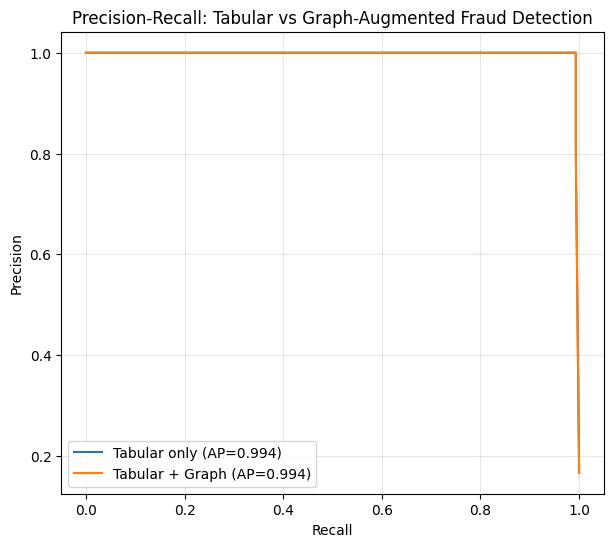

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

sent = df.groupby("sender").agg(n_sent=("TransactionID","count"), total_sent=("amount","sum"),
                                  avg_sent=("amount","mean"), std_sent=("amount","std"),
                                  n_unique_receivers=("receiver","nunique")).reset_index().rename(columns={"sender":"account"})
received = df.groupby("receiver").agg(n_received=("TransactionID","count"), total_received=("amount","sum"),
                                        n_unique_senders=("sender","nunique")).reset_index().rename(columns={"receiver":"account"})
df["is_round"] = (df["amount"] % 50 == 0).astype(int)
round_ratio = df.groupby("sender")["is_round"].mean().reset_index().rename(columns={"sender":"account","is_round":"round_amount_ratio"})

base_df = acc_df[["account","is_ring"]].rename(columns={"is_ring":"label"})
base_df = base_df.merge(sent, on="account", how="left").merge(received, on="account", how="left").merge(round_ratio, on="account", how="left").fillna(0)
full_df = base_df.merge(graph_feats, on="account", how="left").fillna(0)

tabular_cols = ["n_sent","total_sent","avg_sent","std_sent","n_unique_receivers","n_received","total_received","n_unique_senders","round_amount_ratio"]
graph_cols = ["degree","clustering_coef","core_number","community_size"]
y = full_df["label"]

X_tab_tr, X_tab_te, y_tr, y_te = train_test_split(full_df[tabular_cols], y, test_size=0.3, random_state=42, stratify=y)
X_full_tr, X_full_te, _, _ = train_test_split(full_df[tabular_cols+graph_cols], y, test_size=0.3, random_state=42, stratify=y)

model_tab = XGBClassifier(eval_metric="logloss", random_state=42)
model_tab.fit(X_tab_tr, y_tr)
proba_tab = model_tab.predict_proba(X_tab_te)[:,1]
ap_tab = average_precision_score(y_te, proba_tab)

model_full = XGBClassifier(eval_metric="logloss", random_state=42)
model_full.fit(X_full_tr, y_tr)
proba_full = model_full.predict_proba(X_full_te)[:,1]
ap_full = average_precision_score(y_te, proba_full)

print(f"Tabular-only model:        Average Precision = {ap_tab:.4f}")
print(f"Tabular + Graph features:  Average Precision = {ap_full:.4f}")
print(f"Improvement: {100*(ap_full-ap_tab)/ap_tab:.1f}%")

prec_t, rec_t, _ = precision_recall_curve(y_te, proba_tab)
prec_f, rec_f, _ = precision_recall_curve(y_te, proba_full)
plt.figure(figsize=(7,6))
plt.plot(rec_t, prec_t, label=f"Tabular only (AP={ap_tab:.3f})")
plt.plot(rec_f, prec_f, label=f"Tabular + Graph (AP={ap_full:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall: Tabular vs Graph-Augmented Fraud Detection")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("outputs/pr_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from pyvis.network import Network

# Pick the fraud ring community with the most members to visualize
fraud_communities = full_df[full_df["label"] == 1]["community_id"].value_counts()
target_cid = fraud_communities.index[0]
ring_accounts = graph_feats[graph_feats["community_id"] == target_cid]["account"].tolist()

# Build a small subgraph: the ring accounts + their direct neighbors
nodes_to_show = set(ring_accounts)
for acc in ring_accounts:
    nodes_to_show.update(G.neighbors(acc))

subG = G.subgraph(nodes_to_show)

net = Network(height="600px", width="100%", notebook=True, cdn_resources="in_line")
label_map = full_df.set_index("account")["label"].to_dict()
for node in subG.nodes():
    if node in label_map and label_map[node] == 1:
        color = "#e74c3c"   # red = fraud ring account
    elif str(node).startswith("DEV") or str(node).startswith("IP"):
        color = "#95a5a6"   # gray = device/IP node
    else:
        color = "#3498db"   # blue = normal account
    net.add_node(node, label=str(node), color=color)
for u, v in subG.edges():
    net.add_edge(u, v)

net.show("outputs/fraud_ring_visual.html")
print("Saved! Download outputs/fraud_ring_visual.html from the file panel on the left.")

outputs/fraud_ring_visual.html
Saved! Download outputs/fraud_ring_visual.html from the file panel on the left.
